In [1]:
from sklearn import datasets
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import torch
from sklearn.datasets import make_biclusters

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用中文黑体
plt.rcParams['axes.unicode_minus'] = False  # 确保坐标轴负号显示正常

In [2]:
# 加载威斯康星州乳腺癌数据集
cancer_data = datasets.load_breast_cancer()

# 初始化PCA，降至2维
pca = PCA(n_components=2)


X = cancer_data.data
# 对数据进行PCA降维
X_pca = pca.fit_transform(X)

# 目标变量
y = cancer_data.target

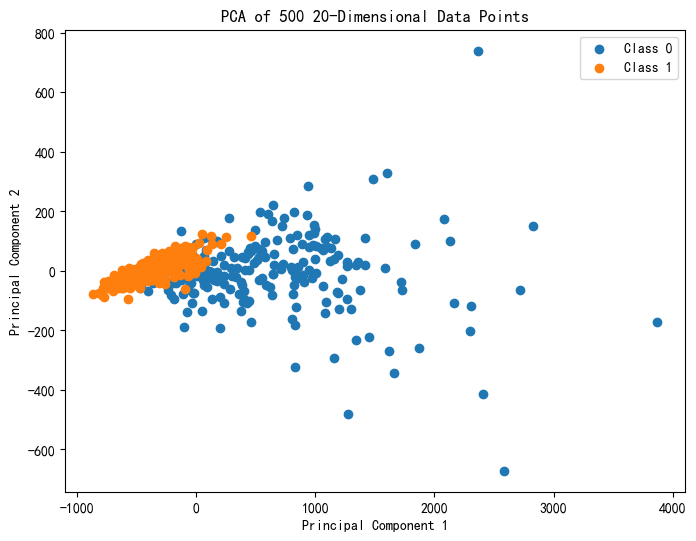

In [3]:
plt.figure(figsize=(8, 6))
for i in range(2):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=f'Class {i}')
plt.title('PCA of 500 20-Dimensional Data Points')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [4]:
x_tensor,y_tensor = torch.tensor(X,dtype=torch.float32),torch.tensor(y)
#归一化
x_tensor = (x_tensor - x_tensor.mean()) / x_tensor.std()

num = 100
x_val,y_val = x_tensor[:num],y_tensor[:num]
x_tensor,y_tensor = x_tensor[num:],y_tensor[num:]
print(f'训练集:{x_tensor.shape[0]},{y_tensor.shape[0]}  测试集：{x_val.shape[0]}')

训练集:469,469  测试集：100


定义线性模型和激活函数
$$ z = W^T X $$
$$ y = \frac{1}{1+e^{-z}}$$

In [5]:
def model(w,b,x):
    '''
    w [num_paramater,1]
    
    x[feature_dim,batch]
    
    w 参数
    b 偏置
    x 输入数据
    
    return:
    输出值 [batch,1]
    '''
    y = torch.matmul(w.T,x.permute(1,0)) + b
    
    out = 1/(1 + torch.exp(-y))
    
    return out.permute(1,0)

def accurate(predict,label):
    
    
    '''
    predict 预测值
    label 标签
    return：
    准确lv
    '''
    predict = torch.where(predict>0.5,1,0)
    out = torch.sum(predict==label)
    
    ac = out/predict.shape[0]
    
    
    return ac * 100

初始化w为$\frac{1}{n}$ n表示w参数的数量

In [6]:
w = torch.tensor(0.0).repeat(30).unsqueeze(1)
b = torch.zeros(1).unsqueeze(1)

In [7]:
x_tensor.shape,y_tensor.shape,x_val.shape,y_val.shape,w.shape,b.shape

(torch.Size([469, 30]),
 torch.Size([469]),
 torch.Size([100, 30]),
 torch.Size([100]),
 torch.Size([30, 1]),
 torch.Size([1, 1]))

ligistic线性模型
$$z = w_{t}x +b$$
激活函数
$$\hat{y} = \frac{1}{1+e^{-z}}$$
损失函数使用交叉熵损失
$$Loss = y log\hat{y} + (1-y)log(1-\hat{y})$$

对参数进行求导后可得到 logistic回归的参数更新方式如下：
$$w_{t+1} = w_t - \alpha \frac{1}{N}\sum_{n=1}^{N}x^{(n)}(y^{n}-\hat{y}^{(n)}_{w_{t}})$$
$$b_{t+1} = b - \alpha \frac{1}{N} \sum_{n=1}^{N}(\hat{y}^{(n)}_{w_{t}}-y) $$

In [8]:
batch = 20
lr = 0.01
epochs= 30
train_ac = []
val_ac = []
for  epoch in range(epochs):
    
    
    predict = model(w,b,x_tensor)   #[batch,1]
    
    minus =  predict - y_tensor.unsqueeze(1)     #batch 1
   
    ac_temp = accurate(predict,y_tensor.unsqueeze(1))
    train_ac.append(ac_temp)
    
    grad = torch.mean(torch.mul(x_tensor,minus),dim=0,keepdim=True).permute(1,0)
    

    w = w - grad * lr
    b = b - torch.mean(minus) * lr
    
    #val
    predict_val = model(w,b,x_val)
    
    ac = accurate(predict_val,y_val.unsqueeze(1))
    val_ac.append(ac)
    print(f'train_ac:{ac_temp:.2f} val_ac:{ac:.2f}%')


train_ac:31.34 val_ac:76.00%
train_ac:55.01 val_ac:76.00%
train_ac:56.72 val_ac:78.00%
train_ac:57.57 val_ac:80.00%
train_ac:59.70 val_ac:81.00%
train_ac:61.62 val_ac:81.00%
train_ac:63.33 val_ac:81.00%
train_ac:66.52 val_ac:83.00%
train_ac:68.44 val_ac:83.00%
train_ac:69.08 val_ac:85.00%
train_ac:71.00 val_ac:85.00%
train_ac:71.86 val_ac:85.00%
train_ac:74.41 val_ac:86.00%
train_ac:75.05 val_ac:89.00%
train_ac:75.91 val_ac:91.00%
train_ac:78.04 val_ac:91.00%
train_ac:79.74 val_ac:91.00%
train_ac:79.74 val_ac:92.00%
train_ac:80.38 val_ac:92.00%
train_ac:80.81 val_ac:92.00%
train_ac:82.73 val_ac:92.00%
train_ac:83.37 val_ac:92.00%
train_ac:84.65 val_ac:94.00%
train_ac:85.29 val_ac:93.00%
train_ac:86.14 val_ac:93.00%
train_ac:86.99 val_ac:93.00%
train_ac:88.06 val_ac:92.00%
train_ac:88.27 val_ac:89.00%
train_ac:88.49 val_ac:89.00%
train_ac:89.13 val_ac:87.00%


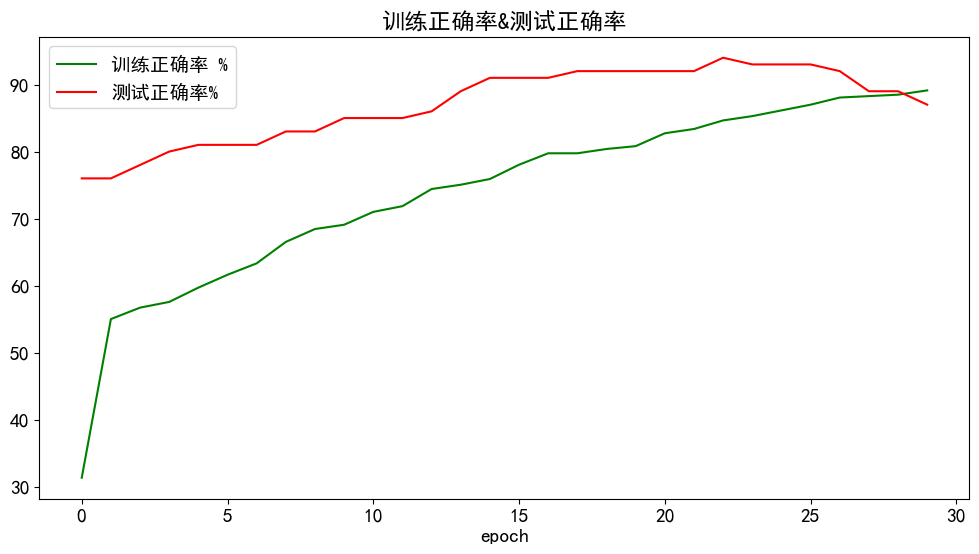

In [14]:
plt.figure(figsize=(12,6))
plt.plot(range(len(train_ac)),train_ac,c='g',label='训练正确率 %')
plt.plot(range(len(val_ac)),val_ac,c='r',label='测试正确率%')
plt.title('训练正确率&测试正确率')
plt.xlabel('epoch')
plt.legend()
plt.show()

# 感知器的实现
感知器是一种简单的二分类模型
$$\hat{y} = sgn(w^Tx)$$
每次错分一个样本时 即$yw^Tx<0$ 就进行一次参数更新
损失函数为：
$$Loss = max(0,-yw^Tx)$$
采用随机梯度下降，将损失函数对w求导得到：
$$
grad = 
\begin{cases}
    0   & \textbf{if} & yw^T>0\\
    -yx   & \textbf{if} & yw^T<0
\end{cases}
$$
所以参数更新的方式：
$$w_{t+1} = w_t + yx$$

In [10]:
def model1(w,x):
    return torch.sum(torch.mul(w,x))
def accuracy(predict,label):
    

    result = torch.sum(predict==label)
    per = result/predict.shape[0]
    
    return per * 100
    

In [11]:
#重新定义一下label
labels = torch.where(y_tensor==0,-1,1)
y_val = torch.where(y_val==0,-1,1)
w = torch.randn(30)      #不能随机初始化为0

In [12]:
lr = 0.001
ac_num = []


for i in range(len(x_tensor)):
    data = x_tensor[i]
    label = labels[i]
    predict = model1(w,data)

    #判断是否需要进行参数更新
    if label * predict < 0:
        w = w + label * data * lr

    #测试
    ac_list = []
    for j in range(len(x_val)):
        temp_x = x_val[j]
        predict_val = model1(w,temp_x)
        if predict_val > 0:
            ac_list.append(1)
        else:
            ac_list.append(-1)
    ac = accuracy(torch.tensor(ac_list),y_val)
    ac_num.append(ac)


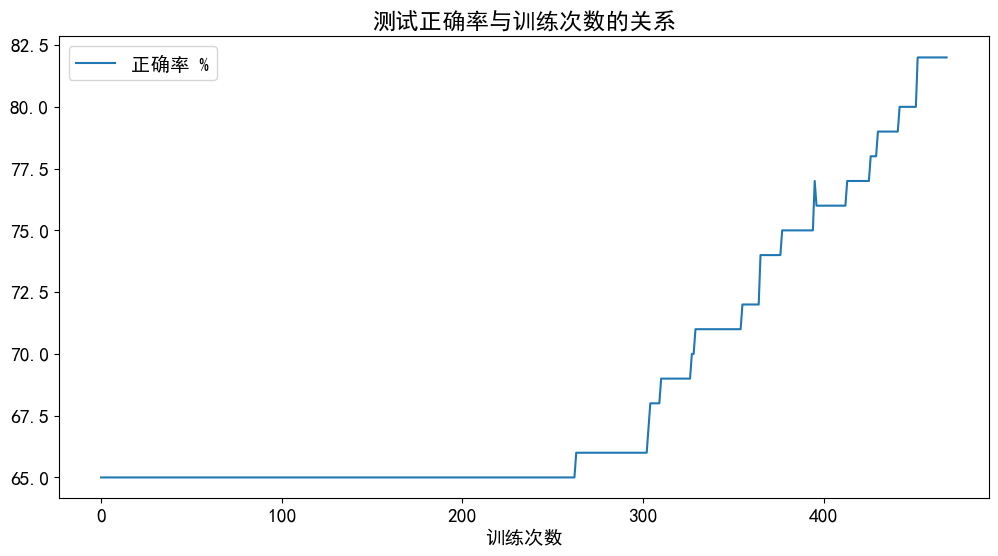

In [15]:
plt.figure(figsize=(12,6))
plt.plot(range(len(ac_num)),ac_num,label="正确率 %")
plt.xlabel('训练次数')
plt.legend()
plt.title('测试正确率与训练次数的关系')
plt.show()